In [1]:
import pandas as pd
from sqlalchemy import create_engine
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import platform
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import statsmodels.api as sm
import ssl
import certifi
from urllib.request import urlopen
import json
from DATA.stock_invest_function import *
import seaborn as sns
import matplotlib.pyplot as pl

In [8]:
def preprocess_quarterly_growth(df: pd.DataFrame) -> pd.DataFrame:
    """
    월별 데이터를 분기별로 집계하고, 전년 동분기 대비 성장률을 계산하는 함수
    """
    df['quarter'] = df['date'].dt.to_period('Q')
    df_quarterly = (
        df.groupby(['root_hs_code', 'quarter'])['value']
          .sum()
          .reset_index()
    )
    df_quarterly['date'] = df_quarterly['quarter'].dt.to_timestamp(how='end')
    df_quarterly.drop(columns=['quarter'], inplace=True)
    df_quarterly['date'] = pd.to_datetime(df_quarterly['date']).dt.date

    df_quarterly = df_quarterly.sort_values(['root_hs_code', 'date'])
    df_quarterly['yoy_value'] = df_quarterly.groupby('root_hs_code')['value'].shift(4)
    df_quarterly['yoy_growth'] = (
        (df_quarterly['value'] - df_quarterly['yoy_value']) / df_quarterly['yoy_value']
    ) * 100

    return df_quarterly


def create_yoy_growth_pivot(df_quarterly: pd.DataFrame,
                             start_date: str = None,
                             end_date: str = None) -> pd.DataFrame:
    """
    전년 동분기 대비 증가율을 pivot 형태로 변환하고 분석기간을 설정할 수 있는 함수
    
    Parameters:
    - df_quarterly (DataFrame): 'root_hs_code', 'date', 'yoy_growth' 포함된 데이터
    - start_date (str or None): 분석 시작일 (예: '2015-01-01')
    - end_date (str or None): 분석 종료일 (예: '2023-12-31')

    Returns:
    - pivot_df (DataFrame): 행: date, 열: root_hs_code, 값: yoy_growth
    """
    pivot_df = df_quarterly.pivot(
        index='date',
        columns='root_hs_code',
        values='yoy_growth'
    ).sort_index()

    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.index = pd.to_datetime(pivot_df.index)

    if start_date:
        pivot_df = pivot_df[pivot_df.index >= pd.to_datetime(start_date)]
    if end_date:
        pivot_df = pivot_df[pivot_df.index <= pd.to_datetime(end_date)]

    return pivot_df

def us_trade_pivot_dataframe(df, index_col='date', column_col='hs_code', value_col='expDlr'):
    """
    주어진 DataFrame에서 피벗 테이블을 생성합니다.

    Parameters:
    - df: 원본 DataFrame
    - index_col: 피벗 테이블의 인덱스가 될 열 (기본값 'date')
    - column_col: 피벗 테이블의 컬럼이 될 열 (기본값 'hs_code')
    - value_col: 피벗 테이블의 값이 될 열 (기본값 'expDlr')

    Returns:
    - pivot_df: 피벗 테이블 형태의 DataFrame
    """
    pivot_df = df.pivot(index=index_col, columns=column_col, values=value_col)
    return pivot_df

def analyze_export_trends(pivot_df, n_recent=12, n_top=5):
    """
    수출금액 피벗 테이블을 기반으로 고점 돌파 HS Code와
    YoY 증가율 상위 HS Code를 추출하는 함수.

    inf 값은 자동으로 제외됩니다.

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (value = 수출금액)
    - n_recent: 최근 몇 개월을 기준으로 분석할지 (기본값: 12개월)
    - n_top: 상위 몇 종목을 출력할지 (기본값: 5종목)

    Returns:
    - breakout_codes: 신고점을 갱신한 HS Code 리스트
    - top_yoy_growth_df: 최근 n개월간 YoY 증가율 상위 n개 HS Code의 DataFrame
    """

    # 날짜 기준 정렬
    pivot_df = pivot_df.sort_index()

    # 최근 n개월 데이터 선택
    recent_df = pivot_df.iloc[-n_recent:]
    last_month = recent_df.index[-1]

    # 1. 신고점 돌파한 HS Code 찾기
    breakout_codes = []
    for col in recent_df.columns:
        max_before = recent_df.iloc[:-1][col].max()
        last_value = recent_df.iloc[-1][col]
        if pd.notna(last_value) and last_value > max_before:
            breakout_codes.append(col)

    # 2. 최근 n개월간 YoY 증가율 계산
    yoy_df = pivot_df.copy()
    yoy_df.index = pd.to_datetime(yoy_df.index)

    # 12개월 전 대비 YoY 변화율 (%)
    yoy_change = yoy_df.pct_change(12) * 100
    recent_yoy = yoy_change.iloc[-n_recent:]

    # 평균 YoY 성장률 계산
    mean_yoy_growth = recent_yoy.mean()

    # inf, -inf, NaN 제거
    mean_yoy_growth = mean_yoy_growth.replace([np.inf, -np.inf], np.nan).dropna()

    # 상위 n개 종목 추출
    top_yoy_growth_df = mean_yoy_growth.sort_values(ascending=False).head(n_top).reset_index()
    top_yoy_growth_df.columns = ['HS_Code', f'Mean_YoY_Growth_{n_recent}m (%)']

       # 보기 좋게 숫자 포맷팅 (소수점 2자리까지)
    colname = f'Mean_YoY_Growth_{n_recent}m (%)'
    top_yoy_growth_df[colname] = top_yoy_growth_df[colname].round(2)

    return breakout_codes, top_yoy_growth_df


def get_recent_yoy_growth(pivot_df, hs_code, n_recent=12):
    """
    특정 HS Code의 최근 n개월 YoY 수출 증가율(%)을 반환하는 함수

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (수출금액 피벗 테이블)
    - hs_code: 조회할 HS 코드 (문자열 또는 정수형)
    - n_recent: 최근 몇 개월치를 조회할지 (기본값: 12)

    Returns:
    - pandas.Series: 최근 n개월간 날짜별 YoY 증가율 (소수 둘째 자리 반올림)
    """
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'가 데이터에 없습니다.")

    # 해당 HS Code만 추출
    ts = df[hs_code]

    # YoY 변화율 계산 (%)
    yoy = ts.pct_change(12) * 100

    # 최근 n개월 가져오기
    recent_yoy = yoy.dropna().iloc[-n_recent:]

    # 소수 둘째 자리까지 반올림
    return recent_yoy.round(2)

def find_ma_golden_cross(pivot_df):
    """
    HS Code별로 3/6/12개월 이동평균을 계산하고,
    3-6개월, 3-12개월 골든크로스를 만족하는 HS Code를 반환합니다.

    Parameters:
    - pivot_df: 날짜 인덱스(date), HS Code를 열로 가진 수출금액 피벗 테이블

    Returns:
    - cross_3_6: 3개월 > 6개월 골든크로스 조건을 만족하는 HS Code 리스트
    - cross_3_12: 3개월 > 12개월 골든크로스 조건을 만족하는 HS Code 리스트
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 이동평균 계산
    ma_3 = df.rolling(window=3).mean()
    ma_6 = df.rolling(window=6).mean()
    ma_12 = df.rolling(window=12).mean()

    # 최근 시점 (마지막 row) 기준 비교
    latest_ma_3 = ma_3.iloc[-1]
    latest_ma_6 = ma_6.iloc[-1]
    latest_ma_12 = ma_12.iloc[-1]

    # 골든크로스 조건 필터링
    cross_3_6 = latest_ma_3[latest_ma_3 > latest_ma_6].dropna().index.tolist()
    cross_3_12 = latest_ma_3[latest_ma_3 > latest_ma_12].dropna().index.tolist()

    return cross_3_6, cross_3_12

def plot_export_with_moving_averages(pivot_df, hs_code, start_date=None):
    """
    특정 HS Code의 수출금액과 3, 6, 12개월 이동평균선을 시각화하는 함수

    Parameters:
    - pivot_df: 날짜 인덱스를 가진 HS Code별 수출금액 피벗 테이블
    - hs_code: 시각화할 HS Code (문자열 또는 정수)
    - start_date: 시각화 시작 시점 (문자열 'YYYY-MM-DD' 또는 None)
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'는 데이터에 없습니다.")

    series = df[hs_code]

    # 이동평균 계산
    ma_3 = series.rolling(3).mean()
    ma_6 = series.rolling(6).mean()
    ma_12 = series.rolling(12).mean()

    # 시각화 구간 자르기 (선택사항)
    if start_date:
        series = series[series.index >= start_date]
        ma_3 = ma_3[ma_3.index >= start_date]
        ma_6 = ma_6[ma_6.index >= start_date]
        ma_12 = ma_12[ma_12.index >= start_date]

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(series, label='Monthly Export', color='black', linewidth=2)
    plt.plot(ma_3, label='3-Month MA', linestyle='--')
    plt.plot(ma_6, label='6-Month MA', linestyle='--')
    plt.plot(ma_12, label='12-Month MA', linestyle='--')

    plt.title(f'Export Trend for HS Code {hs_code}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Export Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:  # Linux (예: Google Colab)
    plt.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [23]:
info_path = r"C:\Users\MetaM\Downloads\US_export_HS_code_company_mapping.xlsx"
hs_codes_info = pd.read_excel(info_path)
hs_codes_info['hs_code'] = hs_codes_info['HS Code'].astype('str')


In [5]:
db_info = {
    # 'host': '192.168.0.230',
    'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

# SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

trade_data_df = fetch_table_data(db_info, "us_trade_data")

✅ 'us_trade_data' 테이블에서 13379건의 데이터를 가져왔습니다.


In [6]:
trade_data_df

,date,expDlr,year,month,hs_code,quarter
0,2013-01-31,7.311372e+09,2013,01,880000,2013Q1
1,2013-02-28,6.786829e+09,2013,02,880000,2013Q1
2,2013-03-31,8.886442e+09,2013,03,880000,2013Q1
3,2013-04-30,7.839336e+09,2013,04,880000,2013Q2
4,2013-05-31,9.221946e+09,2013,05,880000,2013Q2
...,...,...,...,...,...,...
13374,2024-12-31,1.677470e+08,2024,12,870830,2024Q4
13375,2025-01-31,2.075184e+08,2025,01,870830,2025Q1
13376,2025-02-28,2.120014e+08,2025,02,870830,2025Q1
13377,2025-03-31,2.127323e+08,2025,03,870830,2025Q1


In [9]:
trade_pivot_df = us_trade_pivot_dataframe(trade_data_df)

print(trade_pivot_df.head())

hs_code          100199       100590        120190       210690       230330  \
date                                                                           
2013-01-31  738003507.0  447856323.0  3.080439e+09  360649367.0  188276858.0   
2013-02-28  844245600.0  442869678.0  2.281144e+09  350565730.0  205793999.0   
2013-03-31  936336637.0  605618304.0  1.154503e+09  404402092.0  196228947.0   
2013-04-30  952592398.0  450858788.0  5.403578e+08  393081981.0  231165275.0   
2013-05-31  804767583.0  427791122.0  3.419560e+08  406519576.0  230465272.0   

hs_code          230400       230910       260300        270112       270900  \
date                                                                           
2013-01-31  628476542.0  117072525.0  141953667.0  9.696044e+08  350767521.0   
2013-02-28  478394388.0  110839741.0  193012636.0  8.124301e+08  390066517.0   
2013-03-31  374201796.0  120316555.0  231385564.0  1.239198e+09  362351824.0   
2013-04-30  233277310.0  106511289.0  2

In [24]:
# pivot_df = pivot_dataframe(...)  # 앞서 만든 피벗 테이블 함수로 만든 데이터프레임
num = 100
breakouts, yoy_top = analyze_export_trends(trade_pivot_df, n_recent=12, n_top=num)

print("신고점 돌파 종목 (HS Code):", breakouts)
print(f"\n최근 12개월 YoY 증가율 상위 {num}개 종목:")
print(yoy_top)

신고점 돌파 종목 (HS Code): ['100590', '260300', '330210', '382499', '480411', '710812', '711590', '841112', '847150', '901890', '902139']

최근 12개월 YoY 증가율 상위 100개 종목:
   HS_Code  Mean_YoY_Growth_12m (%)
0   711590                   711.30
1   847180                   213.33
2   847149                   105.55
3   903141                   101.06
4   847150                    94.16
..     ...                      ...
91  520100                   -15.09
92  270112                   -15.36
93  870333                   -18.52
94  710239                   -18.94
95  870324                   -19.31

[96 rows x 2 columns]


In [25]:
result = get_recent_yoy_growth(trade_pivot_df, hs_code='854231', n_recent=12)
print(result)

date
2024-05-31     21.98
2024-06-30     33.05
2024-07-31    103.28
2024-08-31     66.48
2024-09-30     26.25
2024-10-31     33.12
2024-11-30     32.90
2024-12-31     34.79
2025-01-31     48.20
2025-02-28     49.76
2025-03-31     50.92
2025-04-30     50.12
Name: 854231, dtype: float64


In [26]:
# pivot_df: date index, HS Code columns, value = export amount
cross_3_6, cross_3_12 = find_ma_golden_cross(trade_pivot_df)

print("📈 3개월 > 6개월 이동평균 골든크로스 종목:")
print(cross_3_6)

print("\n📈 3개월 > 12개월 이동평균 골든크로스 종목:")
print(cross_3_12)

📈 3개월 > 6개월 이동평균 골든크로스 종목:
['100199', '100590', '210690', '230910', '260300', '271111', '271113', '271121', '271311', '300212', '300214', '300215', '300241', '300439', '300490', '330210', '330499', '382219', '382499', '390110', '390410', '391990', '392310', '392690', '480411', '520100', '710239', '710391', '710812', '711319', '711590', '732690', '840734', '841112', '841191', '842129', '847150', '847170', '847180', '847330', '847989', '851762', '852351', '853690', '853710', '853890', '854370', '854430', '854442', '870323', '870324', '870333', '870431', '870829', '870830', '870840', '870899', '880000', '901819', '901839', '901890', '902139', '902190', '902790', '903141', '970191', '980110', '988000']

📈 3개월 > 12개월 이동평균 골든크로스 종목:
['100199', '100590', '210690', '230400', '230910', '260300', '271111', '271112', '271113', '271121', '271311', '293719', '300212', '300214', '300439', '300490', '330210', '382219', '382499', '390110', '390120', '390140', '390410', '391990', '392310', '392690', '4

In [27]:
cross_both = list(set(cross_3_6) & set(cross_3_12))
print("\n📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:")
print(cross_both)


📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:
['300490', '210690', '391990', '710812', '260300', '842129', '300439', '902190', '847330', '271111', '271113', '382499', '853890', '870840', '970191', '390110', '901839', '392690', '980110', '300214', '847180', '853710', '854430', '300212', '100199', '230910', '841191', '847150', '870333', '392310', '901890', '902139', '870899', '100590', '880000', '480411', '382219', '852351', '330210', '847989', '271121', '840734', '520100', '841112', '851762', '390410', '711319', '988000', '854370', '847170', '710391', '271311', '854442', '711590', '903141', '870323', '902790']


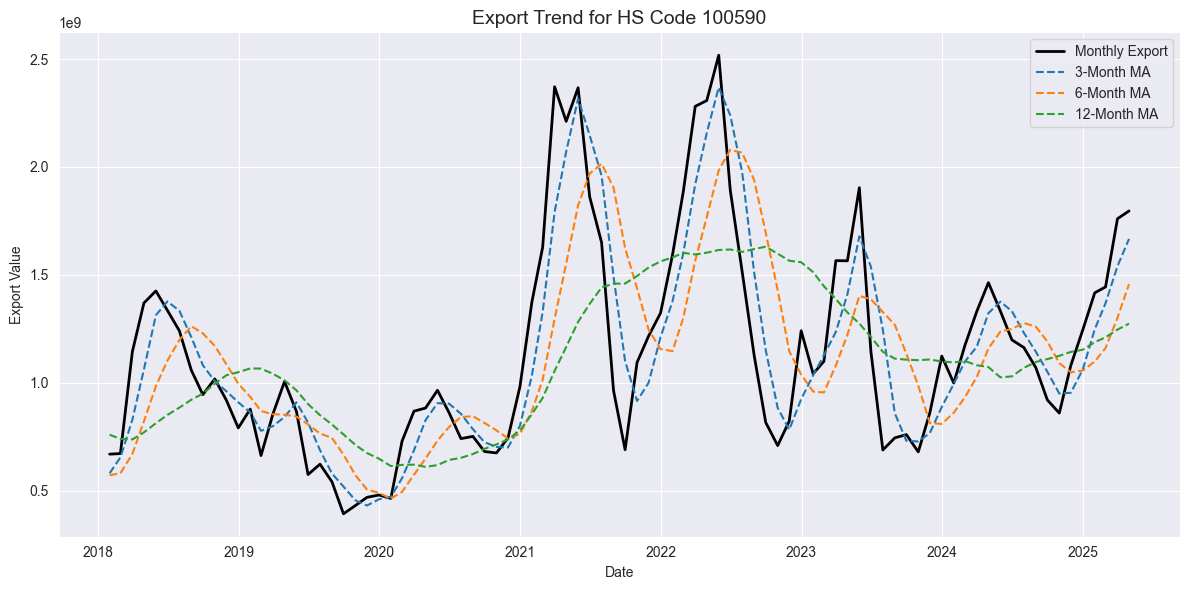

   HS Code    Description                             Company   Ticker hs_code
1   100590  기타 옥수수 (종자 외)  Archer-Daniels-Midland; Bunge Ltd.  ADM; BG  100590


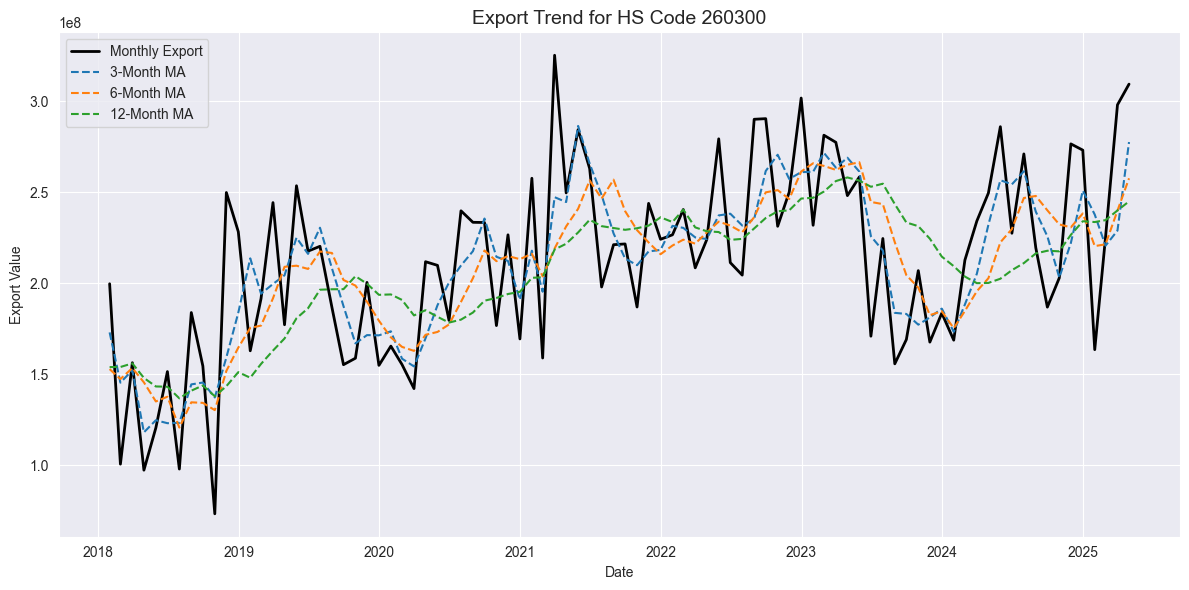

   HS Code Description           Company Ticker hs_code
7   260300       구리 정광  Freeport-McMoRan    FCX  260300


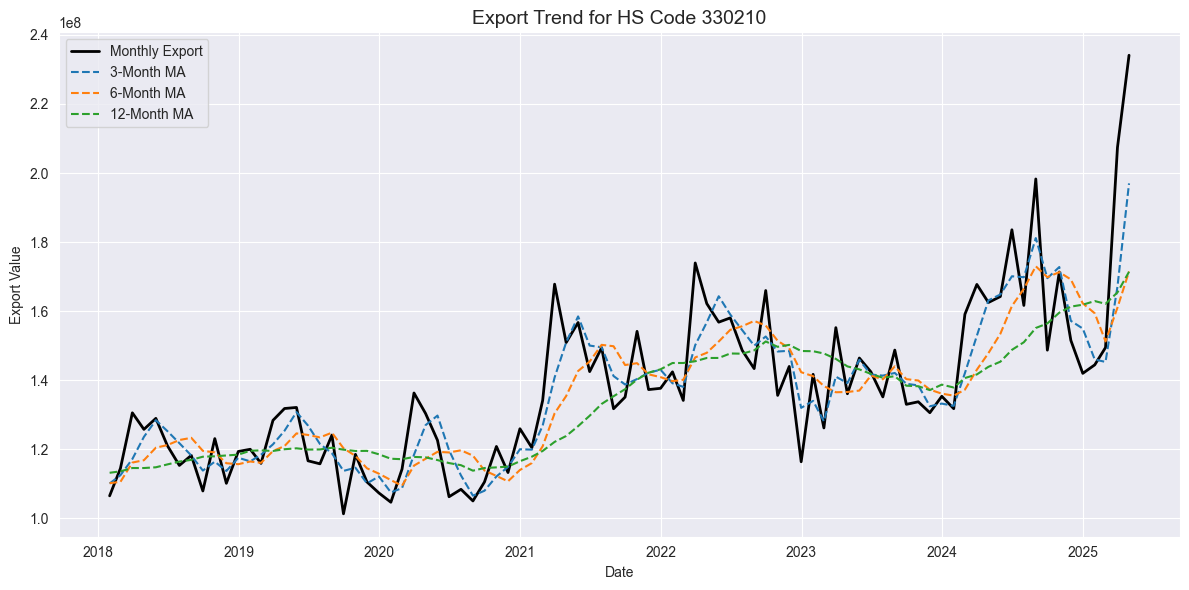

    HS Code Description                  Company    Ticker hs_code
25   330210    향수 및 화장수  Estée Lauder; Coty Inc.  EL; COTY  330210


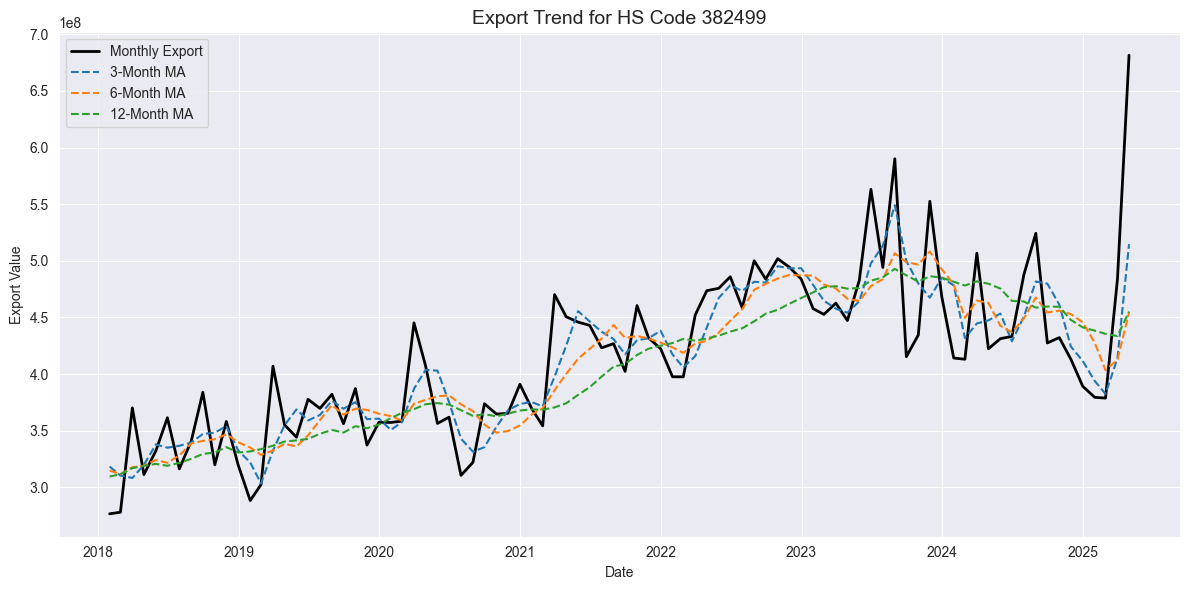

    HS Code       Description           Company   Ticker hs_code
28   382499  기타 화학 제품 (기재 불명)  Dow Inc.; DuPont  DOW; DD  382499


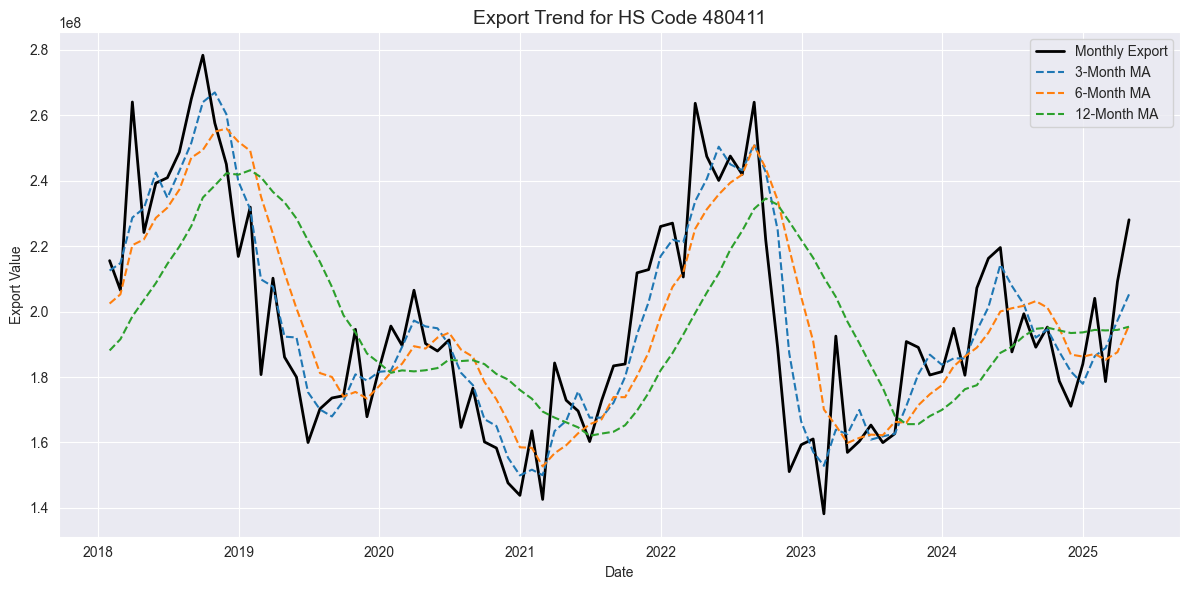

    HS Code    Description                      Company       Ticker hs_code
37   480411  무광택 종이 (롤 상태)  International Paper; Domtar  IP; Private  480411


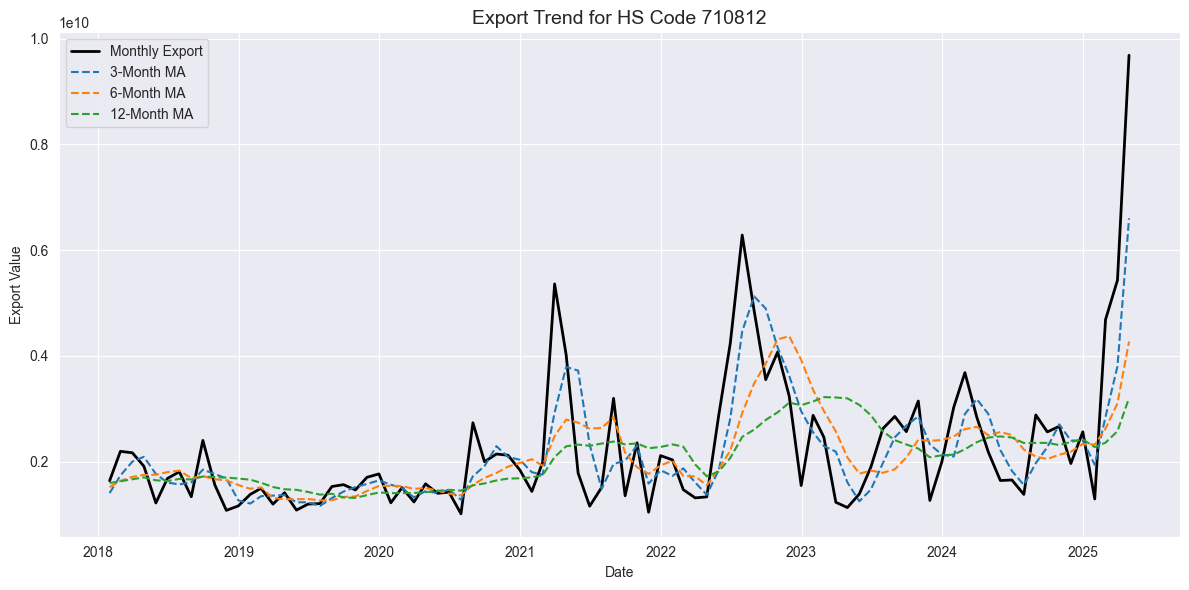

    HS Code      Description                            Company     Ticker  \
41   710812  금, 기타 형태 (비화폐용)  Newmont Corp.; Barrick Gold Corp.  NEM; GOLD   

   hs_code  
41  710812  


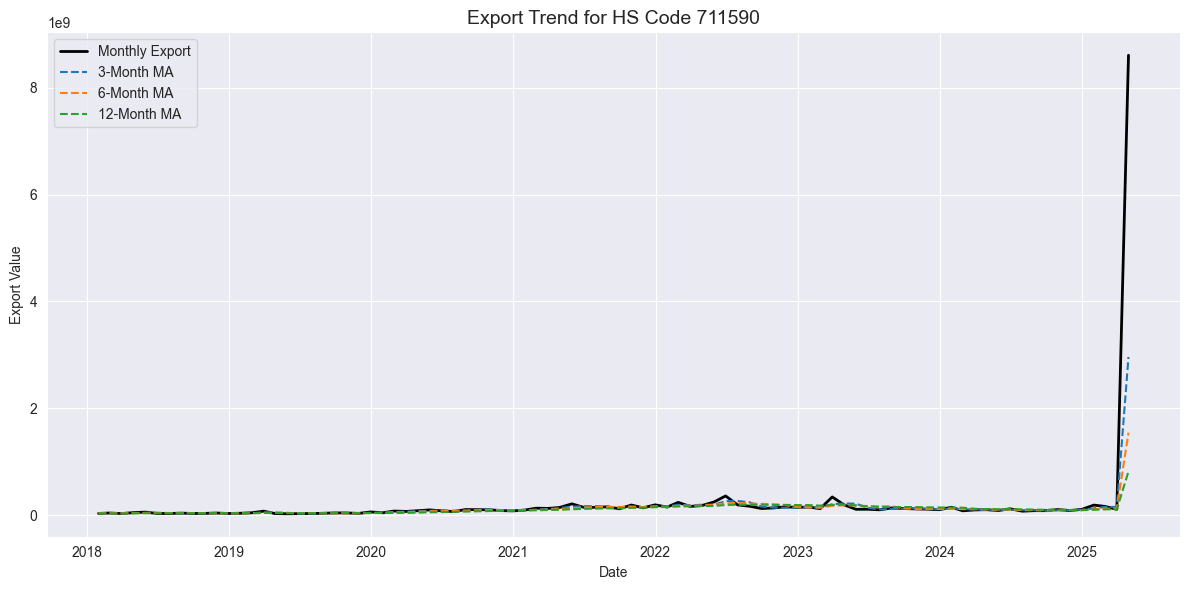

    HS Code    Description                      Company         Ticker hs_code
44   711590  기타 비화폐용 금속 제품  LeachGarner; Materion Corp.  Private; MTRN  711590


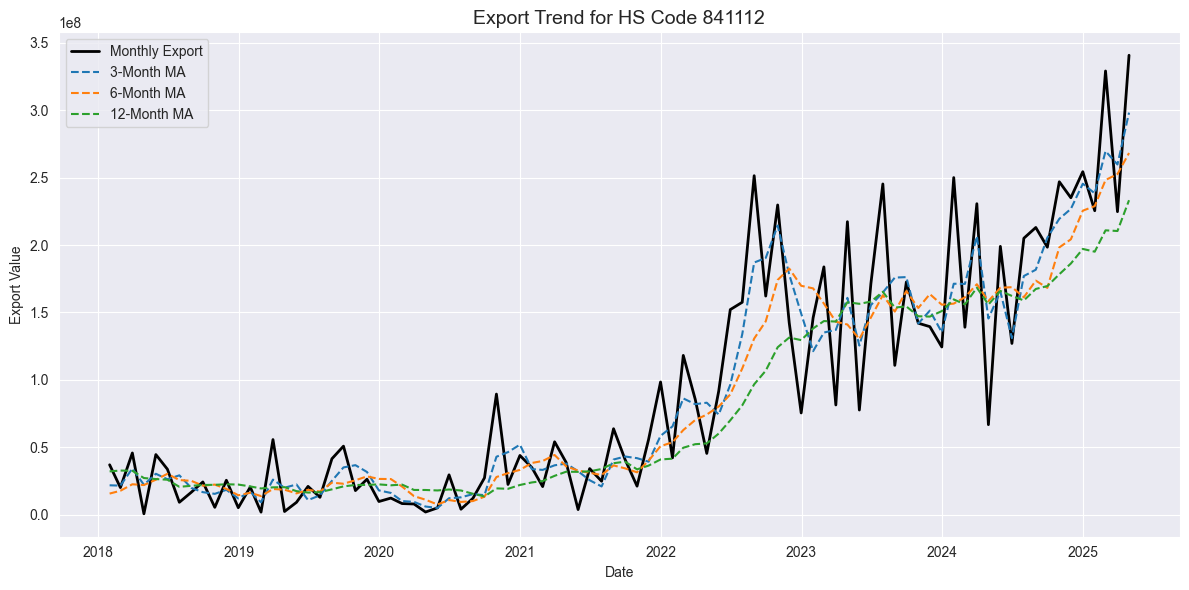

    HS Code Description                            Company   Ticker hs_code
49   841112     터보제트 엔진  General Electric; Pratt & Whitney  GE; RTX  841112


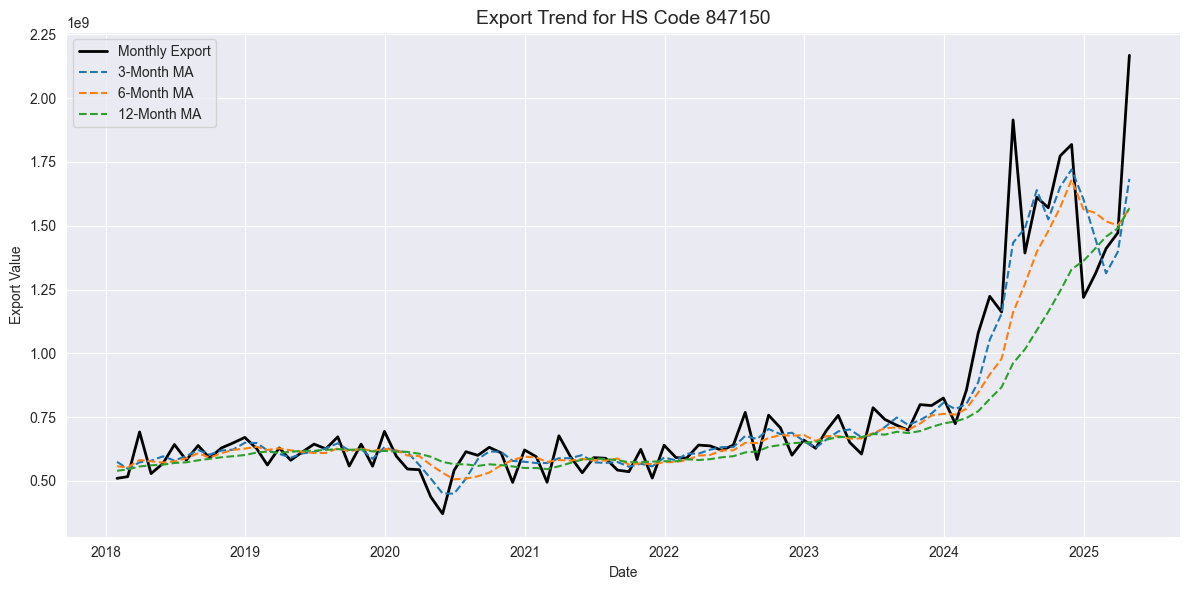

    HS Code  Description           Company     Ticker hs_code
55   847150  디지털 프로세싱 장치  Intel Corp.; AMD  INTC; AMD  847150


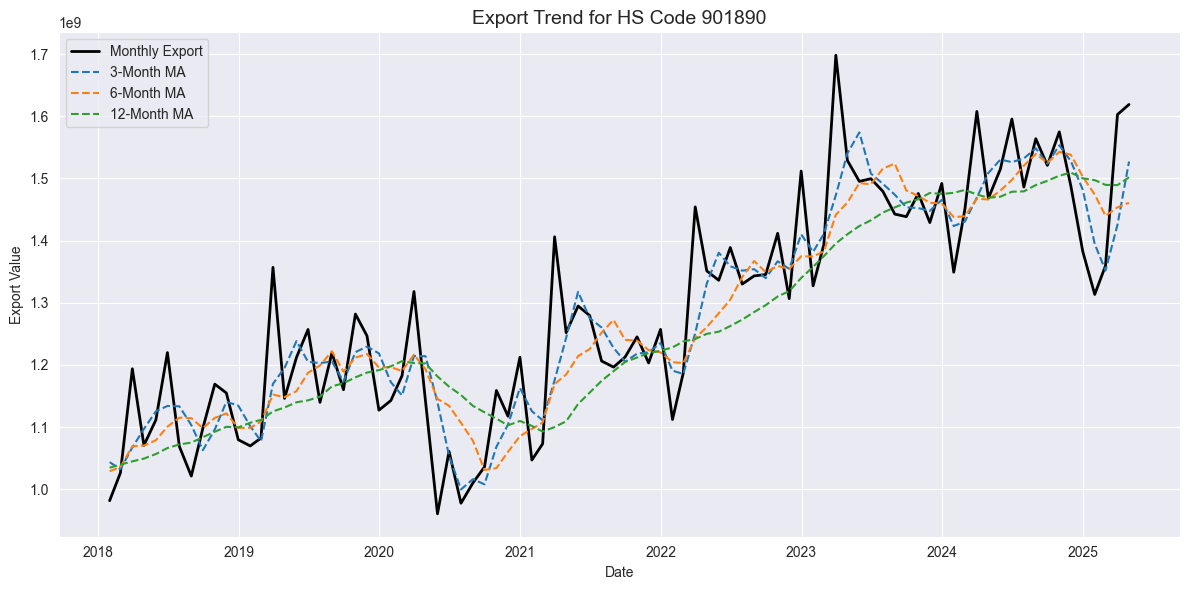

    HS Code Description                       Company    Ticker hs_code
87   901890  기타 외과·치과기기  Stryker Corp.; Zimmer Biomet  SYK; ZBH  901890


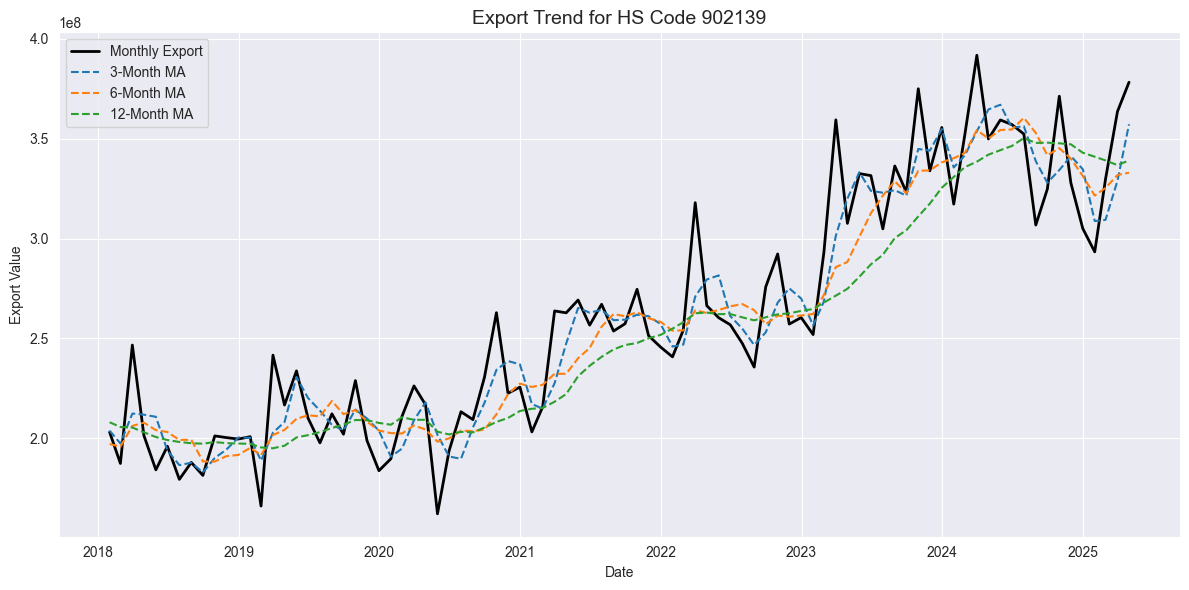

    HS Code Description                        Company    Ticker hs_code
88   902139   인공기관 및 보철  Abiomed; Edwards Lifesciences  ABMD; EW  902139


In [28]:
for hs_code in breakouts:
    info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
    plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
    print(info)

In [16]:
us_main_export_product = pd.DataFrame(trade_pivot_df.columns.tolist())